In [25]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
arff_file_train = arff.loadarff('/content/drive/MyDrive/Colab Notebooks/data/AbnormalHeartbeat_TRAIN.arff')
arff_file_test = arff.loadarff('/content/drive/MyDrive/Colab Notebooks/data/AbnormalHeartbeat_TEST.arff')


df_train = pd.DataFrame(arff_file_train[0])
df_test = pd.DataFrame(arff_file_test[0])

combined_df = pd.concat([df_train, df_test], ignore_index=True)
combined_df['target'] = combined_df['target'].apply(lambda x: 'Abnormal' if str(x) == "b'Abnormal'" else 'Normal')
combined_df['target'] = combined_df['target'].map({'Abnormal': 1, 'Normal': 0})

y = combined_df['target']
X = combined_df.drop('target', axis=1)
X = X.to_numpy()
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

In [26]:
from torch.utils.data import DataLoader, TensorDataset
import torch

n_train = X_train.shape[0]
n_test  = X_test.shape[0]
n_features = X_train.shape[1]

X_train_unflattened = X_train.reshape(n_train, 1, n_features)
X_train_tensor = torch.from_numpy(X_train_unflattened).float()

y_train_tensor = torch.as_tensor(y_train.to_numpy(), dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor,
                        y_train_tensor), batch_size=32)

X_test_unflattened  = X_test.reshape(n_test, 1, n_features)
X_test_tensor = torch.from_numpy(X_test_unflattened).float()
y_test_tensor = torch.as_tensor(y_test.to_numpy(), dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor,
                        y_test_tensor), batch_size=32)

In [48]:
import torchtime.models as models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score

EPOCHS = 200
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA).")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
else:
    device = torch.device("cpu")
    print("Using CPU.")

net = models.InceptionTime(n_inputs=1, n_classes=2, depth=4, n_filters=32, kernel_size=32, use_bottleneck=True, use_residual=True)
net.to(device)

class_counts = torch.tensor([len(y_train) - np.sum(y_train), np.sum(y_train)])  # counts in train set
class_weights = 1.0 / class_counts.float()


class_weights = class_weights.to(device)
cost_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(net.parameters(), lr=0.00001, weight_decay=1e-3)

track_cost = np.zeros(EPOCHS)
for epoch in range(EPOCHS):
    net.train()
    cur_cost = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        cost = cost_fn(outputs, labels)
        cost.backward()
        optimizer.step()
        cur_cost += cost.item()
    track_cost[epoch] = cur_cost
    print(f"Epoch: {epoch} Cost: {cur_cost:.4f}")

Using NVIDIA GPU (CUDA).
Epoch: 0 Cost: 7.6095
Epoch: 1 Cost: 7.5564
Epoch: 2 Cost: 7.5153
Epoch: 3 Cost: 7.4823
Epoch: 4 Cost: 7.4533
Epoch: 5 Cost: 7.4249
Epoch: 6 Cost: 7.3979
Epoch: 7 Cost: 7.3721
Epoch: 8 Cost: 7.3469
Epoch: 9 Cost: 7.3229
Epoch: 10 Cost: 7.2998
Epoch: 11 Cost: 7.2768
Epoch: 12 Cost: 7.2538
Epoch: 13 Cost: 7.2299
Epoch: 14 Cost: 7.2058
Epoch: 15 Cost: 7.1798
Epoch: 16 Cost: 7.1534
Epoch: 17 Cost: 7.1247
Epoch: 18 Cost: 7.0966
Epoch: 19 Cost: 7.0655
Epoch: 20 Cost: 7.0357
Epoch: 21 Cost: 7.0043
Epoch: 22 Cost: 6.9751
Epoch: 23 Cost: 6.9417
Epoch: 24 Cost: 6.9002
Epoch: 25 Cost: 6.8621
Epoch: 26 Cost: 6.8235
Epoch: 27 Cost: 6.7912
Epoch: 28 Cost: 6.7521
Epoch: 29 Cost: 6.7222
Epoch: 30 Cost: 6.6838
Epoch: 31 Cost: 6.6577
Epoch: 32 Cost: 6.6198
Epoch: 33 Cost: 6.5980
Epoch: 34 Cost: 6.5618
Epoch: 35 Cost: 6.5436
Epoch: 36 Cost: 6.5092
Epoch: 37 Cost: 6.4947
Epoch: 38 Cost: 6.4618
Epoch: 39 Cost: 6.4501
Epoch: 40 Cost: 6.4187
Epoch: 41 Cost: 6.4094
Epoch: 42 Cost: 6.3

In [49]:
from sklearn.metrics import f1_score

correct = 0
total = 0
all_preds = []
all_labels = []
net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())   # detach from GPU
        all_labels.extend(labels.cpu().numpy())
print(correct/total)
f1 = f1_score(all_labels, all_preds, average='weighted')
print("F1 Score:", f1)

0.8536585365853658
F1 Score: 0.8555996908532091


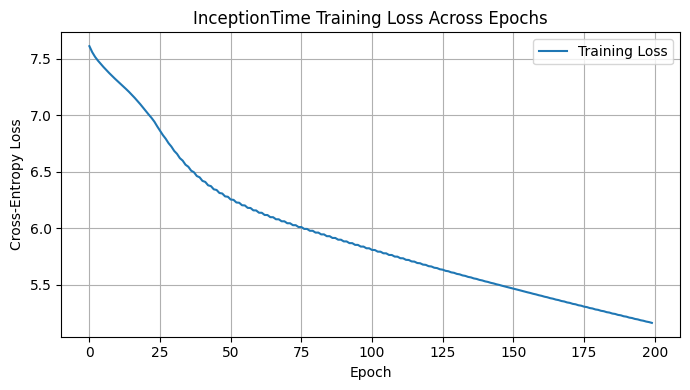

In [50]:
import matplotlib.pyplot as plt

epochs = np.arange(len(track_cost))

plt.figure(figsize=(7, 4))
plt.plot(epochs, track_cost, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("InceptionTime Training Loss Across Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
